# 02 · Normalização de Dados

Demonstração do slide **"Normalização de Dados"**: por que features em escalas diferentes distorcem o KNN, e como z-score/min-max resolvem isso.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt

from src.datasets_utils import make_scale_mismatch_demo
from src.distance_models import KNNClassifier
from src.viz import plot_decision_boundary

plt.rcParams['figure.facecolor'] = 'white'

## 1. Dataset sintético: idade (0–100) x renda (0–50000)

Exatamente o exemplo citado no slide.

idade  -> min/max: 21.2 55.1
renda  -> min/max: 1557.5 11549.3


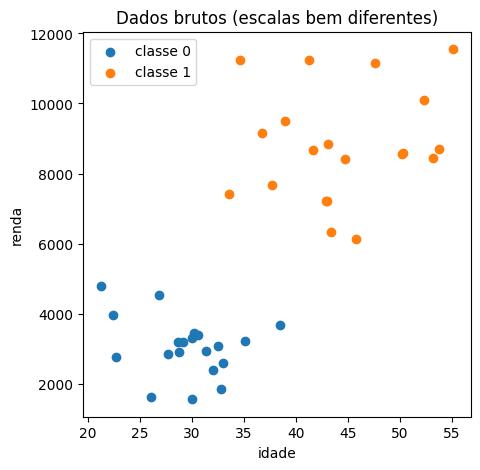

In [2]:
X, y = make_scale_mismatch_demo()
print('idade  -> min/max:', X[:,0].min().round(1), X[:,0].max().round(1))
print('renda  -> min/max:', X[:,1].min().round(1), X[:,1].max().round(1))

fig, ax = plt.subplots(figsize=(5,5))
for c in np.unique(y):
    ax.scatter(X[y==c,0], X[y==c,1], label=f'classe {c}')
ax.set_xlabel('idade'); ax.set_ylabel('renda'); ax.legend()
ax.set_title('Dados brutos (escalas bem diferentes)')
plt.show()

## 2. O que acontece com o KNN sem normalizar?

Como a renda tem uma escala ~100x maior que a idade, ela domina completamente o cálculo de distância — a fronteira de decisão vira, na prática, uma reta vertical baseada só na renda.

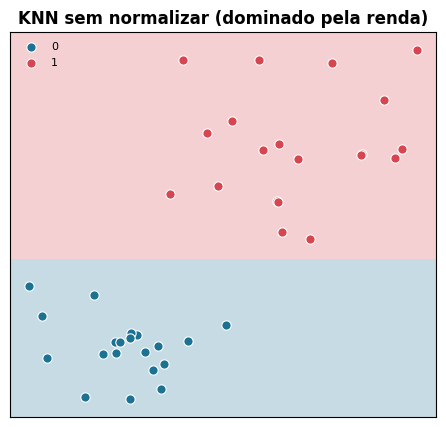

In [3]:
fig, ax = plt.subplots(figsize=(5.5,5))
plot_decision_boundary(KNNClassifier(k=5, weighting='distance'), X, y, ax=ax, title='KNN sem normalizar (dominado pela renda)')
plt.show()

## 3. Normalizando (z-score) e repetindo

$$x' = \dfrac{x - \text{média}}{\text{desvio padrão}}$$

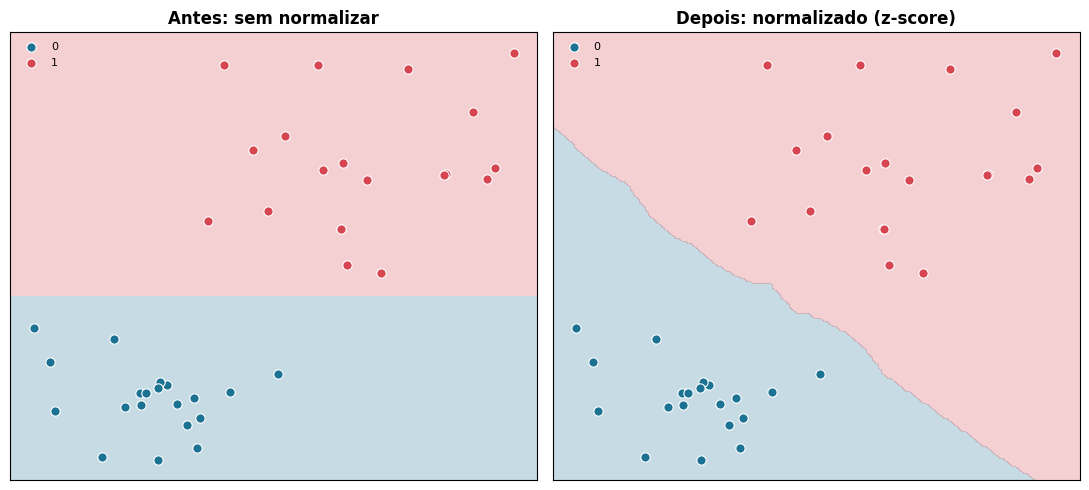

Repare como a fronteira muda de forma drasticamente: agora AMBAS as features contribuem para a distância.


In [4]:
from sklearn.preprocessing import StandardScaler
X_norm = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(11,5))
plot_decision_boundary(KNNClassifier(k=5, weighting='distance'), X, y, ax=axes[0], title='Antes: sem normalizar')
plot_decision_boundary(KNNClassifier(k=5, weighting='distance'), X_norm, y, ax=axes[1], title='Depois: normalizado (z-score)')
plt.tight_layout(); plt.show()
print('Repare como a fronteira muda de forma drasticamente: agora AMBAS as features contribuem para a distância.')

## 4. Comparando z-score vs. min-max

$$\text{min-max: } x' = \dfrac{x - \min}{\max - \min}$$

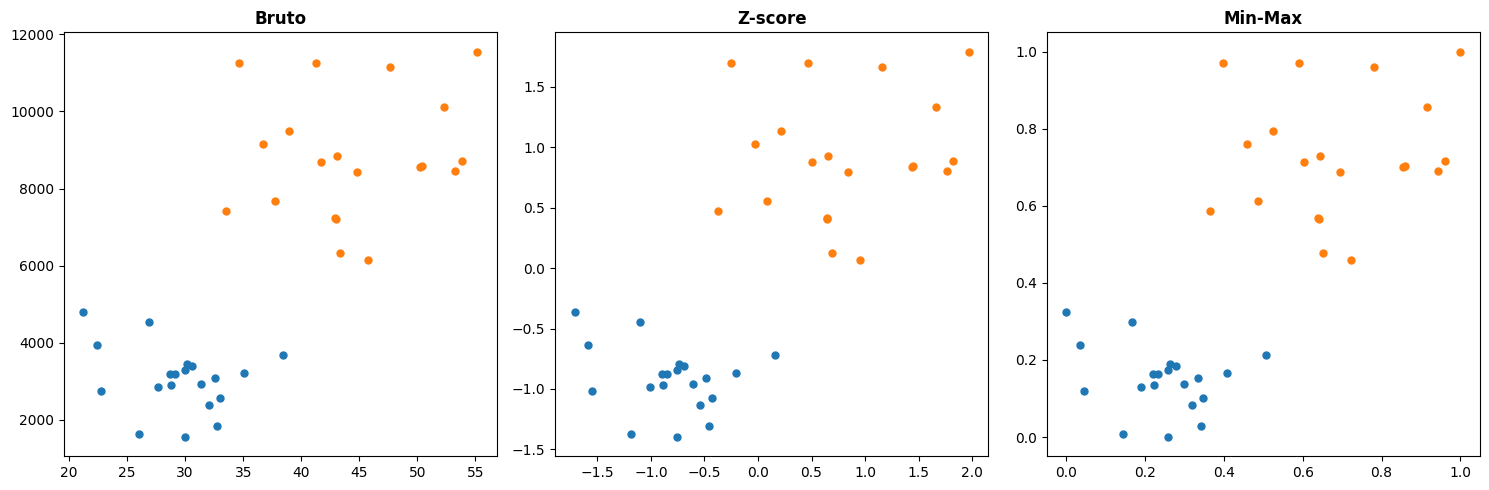

In [5]:
from sklearn.preprocessing import MinMaxScaler
X_minmax = MinMaxScaler().fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, Xi, title in zip(axes, [X, X_norm, X_minmax], ['Bruto', 'Z-score', 'Min-Max']):
    for c in np.unique(y):
        ax.scatter(Xi[y==c,0], Xi[y==c,1], s=25)
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Quantificando o impacto: acurácia com e sem normalização

Usando validação cruzada, num dataset real (Breast Cancer), onde as features realmente têm escalas muito diferentes.

In [6]:
from sklearn.model_selection import cross_val_score
from datasets_utils import load_classification_dataset

X_train, X_test, y_train, y_test, _ = load_classification_dataset('breast_cancer', scale=False)
X_train_norm, X_test_norm, _, _, _ = load_classification_dataset('breast_cancer', scale=True)

modelo = KNNClassifier(k=7, weighting='distance')
scores_sem = cross_val_score(modelo, X_train, y_train, cv=5)
scores_com = cross_val_score(modelo, X_train_norm, y_train, cv=5)

print(f'Acurácia média SEM normalizar: {scores_sem.mean():.4f} (+/- {scores_sem.std():.4f})')
print(f'Acurácia média COM normalizar: {scores_com.mean():.4f} (+/- {scores_com.std():.4f})')

Acurácia média SEM normalizar: 0.9373 (+/- 0.0175)
Acurácia média COM normalizar: 0.9523 (+/- 0.0093)


---
**Nota para o FEMa:** o FEMa também interpola por distância — a normalização é igualmente obrigatória lá. Basta reaproveitar `load_classification_dataset(..., scale=True)` de `src/datasets_utils.py`.